# AML Detection: Model Training & Selection

**Objective.** Train and compare several classifiers on the chronological, leakage-safe feature splits prepared in the previous notebook.

### Experimental protocol
- `train / validation / test` are loaded **after categorical encoding**;
- no categorical preprocessing or one-hot encoding is repeated here;
- the majority class is undersampled only in the fitting subset;
- inverse-probability sample weights compensate for negative-class undersampling;
- **PR-AUC** is the primary model-selection metric;
- Optuna tuning and early stopping use the validation split only;
- the test split remains untouched until the final champion is selected.

> **Important:** this notebook assumes that `load_dataset_splits()` returns fully numeric encoded features and a separate binary target for each split.

## 1. Setup

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna
from optuna.integration import CatBoostPruningCallback

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from aml.data.load import load_dataset_splits

optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
from optuna.exceptions import ExperimentalWarning

warnings.filterwarnings(
    "ignore",
    category=ExperimentalWarning,
)

SEED = 42
NEGATIVE_SAMPLE_RATIO = 0.39

CATBOOST_TRIALS = 20
LIGHTGBM_TRIALS = 30
XGBOOST_TRIALS = 20
EARLY_STOPPING_ROUNDS = 100

## 2. Load Encoded Chronological Splits

The preprocessing contract is intentionally simple: feature engineering and target encoding have already been completed upstream. This notebook therefore validates the split schema and trains models directly on the encoded feature matrix.

In [2]:
splits = load_dataset_splits()

(X_train, y_train), (X_val, y_val), (X_test, y_test) = (
    splits["train"],
    splits["val"],
    splits["test"],
)

assert X_train.columns.equals(X_val.columns), "Train and validation columns differ"
assert X_train.columns.equals(X_test.columns), "Train and test columns differ"
assert not X_train.columns.duplicated().any(), "Duplicate feature names detected"

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
]:
    non_numeric = X_split.select_dtypes(exclude=np.number).columns.tolist()
    assert not non_numeric, (
        f"{split_name} contains non-numeric columns after encoding: {non_numeric}"
    )
    assert set(pd.unique(y_split)).issubset({0, 1}), (
        f"{split_name} target must be binary"
    )
    assert len(X_split) == len(y_split), (
        f"{split_name}: X and y row counts differ"
    )

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_val), len(X_test)],
        "features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
        "positives": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
        "prevalence": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)

split_summary.style.format({"prevalence": "{:.6f}"})

,rows,features,positives,prevalence
train,4846503,65,2231,0.000460
validation,1038436,65,583,0.000561
test,1039102,65,751,0.000723


## 3. Weighted Majority-Class Undersampling

All positive training rows are retained. Only a fixed fraction of negatives is used for model fitting, while sampled negatives receive inverse-probability weights.

The validation and test sets are **never undersampled**.

In [5]:
y_array = y_train.to_numpy()
positive_positions = np.flatnonzero(y_array == 1)
negative_positions = np.flatnonzero(y_array == 0)

rng = np.random.default_rng(SEED)
negative_sample_size = max(
    1,
    int(NEGATIVE_SAMPLE_RATIO * len(negative_positions)),
)
sampled_negative_positions = rng.choice(
    negative_positions,
    size=negative_sample_size,
    replace=False,
)

fit_positions = np.sort(
    np.concatenate([positive_positions, sampled_negative_positions])
)

X_fit = X_train.iloc[fit_positions].reset_index(drop=True)
y_fit = y_train.iloc[fit_positions].reset_index(drop=True)

negative_weight = len(negative_positions) / negative_sample_size
sample_weight = np.where(
    y_fit.to_numpy() == 0,
    negative_weight,
    1.0,
).astype("float32")

sampling_summary = pd.Series(
    {
        "full_train_rows": len(X_train),
        "fit_rows": len(X_fit),
        "fit_fraction": len(X_fit) / len(X_train),
        "positive_rows_kept": int((y_fit == 1).sum()),
        "negative_rows_sampled": int((y_fit == 0).sum()),
        "negative_sampling_ratio": NEGATIVE_SAMPLE_RATIO,
        "negative_inverse_weight": negative_weight,
    },
    name="weighted undersampling",
)

sampling_summary

full_train_rows            4.846503e+06
fit_rows                   1.891497e+06
fit_fraction               3.902808e-01
positive_rows_kept         2.231000e+03
negative_rows_sampled      1.889266e+06
negative_sampling_ratio    3.900000e-01
negative_inverse_weight    2.564103e+00
Name: weighted undersampling, dtype: float64

## 4. Evaluation Helpers

PR-AUC is the primary metric because the laundering class is extremely rare. ROC-AUC is reported as a secondary ranking metric.

In [6]:
def ranking_metrics(
    y_true: pd.Series | np.ndarray,
    scores: np.ndarray,
) -> dict[str, float]:
    return {
        "PR-AUC": average_precision_score(y_true, scores),
        "ROC-AUC": roc_auc_score(y_true, scores),
    }


validation_scores: dict[str, np.ndarray] = {}
trained_models: dict[str, object] = {}


## 5. Training

### 5.1. Logistic Regression Baseline

The encoded split is already numeric, so no categorical preprocessing is required. Standardization is applied **only** to Logistic Regression; tree-based models use the encoded features directly.

In [7]:
lr_scaler = StandardScaler()

X_fit_lr = lr_scaler.fit_transform(X_fit)
X_val_lr = lr_scaler.transform(X_val)

logistic_model = LogisticRegression(
    C=1.0,
    penalty="l2",
    max_iter=500,
    random_state=SEED,
)

logistic_model.fit(
    X_fit_lr,
    y_fit,
    sample_weight=sample_weight,
)

validation_scores["Logistic Regression"] = logistic_model.predict_proba(
    X_val_lr
)[:, 1]
trained_models["Logistic Regression"] = logistic_model

ranking_metrics(
    y_val,
    validation_scores["Logistic Regression"],
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

{'PR-AUC': 0.12542683487221737, 'ROC-AUC': 0.9481036701940982}

### 5.2. CatBoost

CatBoost is trained on the same encoded numeric representation as the other tree models. Optuna tunes the main tree-complexity and regularization parameters; the final model is then refit with a larger iteration budget and early stopping.


In [8]:
def objective_catboost(trial: optuna.Trial) -> float:
    pruning_callback = CatBoostPruningCallback(trial, "PRAUC")

    model = CatBoostClassifier(
        iterations=800,
        learning_rate=trial.suggest_float(
            "learning_rate", 0.015, 0.12, log=True
        ),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float(
            "l2_leaf_reg", 0.5, 20.0, log=True
        ),
        random_strength=trial.suggest_float(
            "random_strength", 1e-3, 5.0, log=True
        ),
        bagging_temperature=trial.suggest_float(
            "bagging_temperature", 0.0, 3.0
        ),
        loss_function="Logloss",
        eval_metric="PRAUC",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )

    model.fit(
        X_fit,
        y_fit,
        sample_weight=sample_weight,
        eval_set=(X_val, y_val),
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        callbacks=[pruning_callback],
    )

    pruning_callback.check_pruned()

    scores = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, scores)


cat_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=100),
)

cat_study.optimize(
    objective_catboost,
    n_trials=CATBOOST_TRIALS,
    show_progress_bar=True,
)

pd.Series(
    {
        "best_validation_PR-AUC": cat_study.best_value,
        **cat_study.best_params,
    },
    name="CatBoost tuning",
)

  0%|          | 0/20 [00:00<?, ?it/s]

/var/folders/pd/z0tg5b153hxf56vybr71chxm0000gn/T/ipykernel_60409/886744846.py:2: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_callback = CatBoostPruningCallback(trial, "PRAUC")
/var/folders/pd/z0tg5b153hxf56vybr71chxm0000gn/T/ipykernel_60409/886744846.py:2: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_callback = CatBoostPruningCallback(trial, "PRAUC")
/var/folders/pd/z0tg5b153hxf56vybr71chxm0000gn/T/ipykernel_60409/886744846.py:2: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_callback = CatBoostPruningCallback(trial, "PRAUC")
/var/folders/pd/z0tg5b153hxf56vybr71chxm0000gn/T/ipykernel_60409/886744846.py:2: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in t

best_validation_PR-AUC    0.273129
learning_rate             0.026087
depth                     8.000000
l2_leaf_reg               1.760984
random_strength           4.518589
bagging_temperature       1.755522
Name: CatBoost tuning, dtype: float64

In [9]:
catboost_model = CatBoostClassifier(
    **cat_study.best_params,
    iterations=2200,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=SEED,
    allow_writing_files=False,
    verbose=False,
    thread_count=-1,
)

catboost_model.fit(
    X_fit,
    y_fit,
    sample_weight=sample_weight,
    eval_set=(X_val, y_val),
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
)

validation_scores["CatBoost"] = catboost_model.predict_proba(X_val)[:, 1]
trained_models["CatBoost"] = catboost_model

ranking_metrics(y_val, validation_scores["CatBoost"])

{'PR-AUC': 0.2731286563239977, 'ROC-AUC': 0.9758884178461975}

### 5.3. LightGBM

LightGBM is tuned directly on encoded features. `positive_boost` is treated as an experimental class-weight multiplier rather than a LightGBM model parameter.

In [10]:
def objective_lightgbm(trial: optuna.Trial) -> float:
    positive_boost = trial.suggest_float(
        "positive_boost", 1.0, 30.0, log=True
    )

    params = {
        "n_estimators": 2500,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.015, 0.12, log=True
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", 10, 100, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 20, 300, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.65, 1.0
        ),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.65, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-4, 10.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-3, 20.0, log=True
        ),
        "objective": "binary",
        "verbosity": -1,
        "n_jobs": -1,
        "random_state": SEED,
    }

    weights = sample_weight.copy()
    weights[y_fit.to_numpy() == 1] *= positive_boost

    model = LGBMClassifier(**params)
    model.fit(
        X_fit,
        y_fit,
        sample_weight=weights,
        eval_X=X_val,
        eval_y=y_val,
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(
                EARLY_STOPPING_ROUNDS,
                verbose=False,
            )
        ],
    )

    scores = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, scores)


lgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

lgb_study.optimize(
    objective_lightgbm,
    n_trials=LIGHTGBM_TRIALS,
    show_progress_bar=True,
)

pd.Series(
    {
        "best_validation_PR-AUC": lgb_study.best_value,
        **lgb_study.best_params,
    },
    name="LightGBM tuning",
)

  0%|          | 0/30 [00:00<?, ?it/s]

best_validation_PR-AUC      0.293711
positive_boost              1.371571
learning_rate               0.063642
num_leaves                 24.000000
max_depth                   7.000000
min_child_samples         105.000000
subsample                   0.859586
colsample_bytree            0.865503
reg_alpha                   0.009265
reg_lambda                  8.730092
Name: LightGBM tuning, dtype: float64

In [11]:
lgb_best_params = lgb_study.best_params.copy()
lgb_positive_boost = lgb_best_params.pop("positive_boost")

lgb_model = LGBMClassifier(
    **lgb_best_params,
    n_estimators=2500,
    subsample_freq=1,
    objective="binary",
    verbosity=-1,
    n_jobs=-1,
    random_state=SEED,
)

lgb_weights = sample_weight.copy()
lgb_weights[y_fit.to_numpy() == 1] *= lgb_positive_boost

lgb_model.fit(
    X_fit,
    y_fit,
    sample_weight=lgb_weights,
    eval_X=X_val,
    eval_y=y_val,
    eval_metric="average_precision",
    callbacks=[
        lgb.early_stopping(
            EARLY_STOPPING_ROUNDS,
            verbose=False,
        )
    ],
)

validation_scores["LightGBM"] = lgb_model.predict_proba(X_val)[:, 1]
trained_models["LightGBM"] = lgb_model

ranking_metrics(y_val, validation_scores["LightGBM"])

{'PR-AUC': 0.29371068035559306, 'ROC-AUC': 0.9762759443459126}

### 5.4. XGBoost

XGBoost uses histogram-based tree construction. The same boosting-round budget, histogram binning, and early-stopping policy are used during tuning and final fitting.

In [12]:
def objective_xgboost(trial: optuna.Trial) -> float:
    positive_boost = trial.suggest_float(
        "positive_boost", 1.0, 30.0, log=True
    )

    model = XGBClassifier(
        n_estimators=2500,
        learning_rate=trial.suggest_float(
            "learning_rate", 0.015, 0.12, log=True
        ),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        min_child_weight=trial.suggest_float(
            "min_child_weight", 1.0, 100.0, log=True
        ),
        subsample=trial.suggest_float(
            "subsample", 0.65, 1.0
        ),
        colsample_bytree=trial.suggest_float(
            "colsample_bytree", 0.65, 1.0
        ),
        gamma=trial.suggest_float(
            "gamma", 1e-5, 5.0, log=True
        ),
        reg_alpha=trial.suggest_float(
            "reg_alpha", 1e-5, 10.0, log=True
        ),
        reg_lambda=trial.suggest_float(
            "reg_lambda", 1e-3, 20.0, log=True
        ),
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        max_bin=128,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        n_jobs=-1,
        scale_pos_weight=positive_boost,
        random_state=SEED,
    )

    model.fit(
        X_fit,
        y_fit,
        sample_weight=sample_weight,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    scores = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, scores)


xgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

xgb_study.optimize(
    objective_xgboost,
    n_trials=XGBOOST_TRIALS,
    show_progress_bar=True,
)

pd.Series(
    {
        "best_validation_PR-AUC": xgb_study.best_value,
        **xgb_study.best_params,
    },
    name="XGBoost tuning",
)

  0%|          | 0/20 [00:00<?, ?it/s]

best_validation_PR-AUC    0.300597
positive_boost            2.226761
learning_rate             0.046227
max_depth                 8.000000
min_child_weight          6.852219
subsample                 0.998631
colsample_bytree          0.927350
gamma                     0.000154
reg_alpha                 0.004725
reg_lambda                0.001880
Name: XGBoost tuning, dtype: float64

In [13]:
xgb_best_params = xgb_study.best_params.copy()
xgb_positive_boost = xgb_best_params.pop("positive_boost")

xgb_model = XGBClassifier(
    **xgb_best_params,
    n_estimators=2500,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    max_bin=128,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    n_jobs=-1,
    scale_pos_weight=xgb_positive_boost,
    random_state=SEED,
)

xgb_model.fit(
    X_fit,
    y_fit,
    sample_weight=sample_weight,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

validation_scores["XGBoost"] = xgb_model.predict_proba(X_val)[:, 1]
trained_models["XGBoost"] = xgb_model

ranking_metrics(y_val, validation_scores["XGBoost"])

{'PR-AUC': 0.300596613129103, 'ROC-AUC': 0.976152380609185}

## 6. Model Selection on Validation

All candidate models are ranked by validation PR-AUC. The test set is not consulted during this decision.

In [14]:
validation_results = pd.DataFrame(
    {
        model_name: ranking_metrics(y_val, scores)
        for model_name, scores in validation_scores.items()
    }
).T.sort_values("PR-AUC", ascending=False)

champion_name = validation_results.index[0]

print(f"Champion by validation PR-AUC: {champion_name}")
validation_results.style.format("{:.4f}")

Champion by validation PR-AUC: XGBoost


,PR-AUC,ROC-AUC
XGBoost,0.3006,0.9762
LightGBM,0.2937,0.9763
CatBoost,0.2731,0.9759
Logistic Regression,0.1254,0.9481


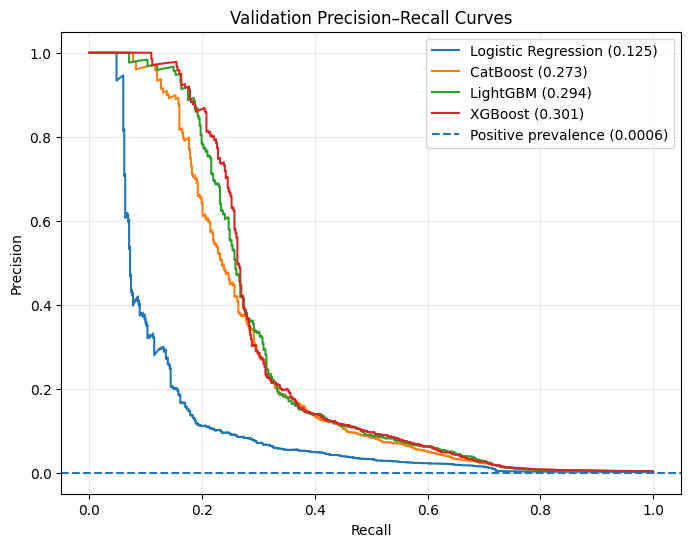

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, scores in validation_scores.items():
    precision, recall, _ = precision_recall_curve(y_val, scores)
    pr_auc = average_precision_score(y_val, scores)
    ax.plot(
        recall,
        precision,
        label=f"{model_name} ({pr_auc:.3f})",
    )

ax.axhline(
    y_val.mean(),
    linestyle="--",
    label=f"Positive prevalence ({y_val.mean():.4f})",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Validation Precision–Recall Curves")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 11. Final Hold-Out Test Evaluation

Only the model selected on validation is evaluated on the test split. This preserves the test set as the final unbiased estimate of generalization performance.

In [16]:
test_scores = {}
test_results = {}

for model_name, model in trained_models.items():
    if model_name == "Logistic Regression":
        X_test_model = lr_scaler.transform(X_test)
    else:
        X_test_model = X_test

    scores = model.predict_proba(X_test_model)[:, 1]

    test_scores[model_name] = scores
    test_results[model_name] = ranking_metrics(
        y_test,
        scores,
    )


test_results = pd.DataFrame(test_results).T

final_results = (
    validation_results
    .add_prefix("validation_")
    .join(
        test_results.add_prefix("test_"),
        how="inner",
    )
)

final_results["PR-AUC_delta"] = (
    final_results["test_PR-AUC"]
    - final_results["validation_PR-AUC"]
)

final_results["PR-AUC_relative_delta_pct"] = (
    final_results["test_PR-AUC"]
    / final_results["validation_PR-AUC"]
    - 1
) * 100

final_results = final_results.sort_values(
    "test_PR-AUC",
    ascending=False,
)

final_results.style.format(
    {
        "validation_PR-AUC": "{:.4f}",
        "validation_ROC-AUC": "{:.4f}",
        "test_PR-AUC": "{:.4f}",
        "test_ROC-AUC": "{:.4f}",
        "PR-AUC_delta": "{:+.4f}",
        "PR-AUC_relative_delta_pct": "{:+.2f}%",
    }
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,validation_PR-AUC,validation_ROC-AUC,test_PR-AUC,test_ROC-AUC,PR-AUC_delta,PR-AUC_relative_delta_pct
LightGBM,0.2937,0.9763,0.3795,0.9774,+0.0858,+29.21%
XGBoost,0.3006,0.9762,0.3749,0.9671,+0.0743,+24.73%
CatBoost,0.2731,0.9759,0.3459,0.9740,+0.0728,+26.66%
Logistic Regression,0.1254,0.9481,0.0714,0.9573,-0.0540,-43.07%


In [18]:
validation_winner = validation_results["PR-AUC"].idxmax()
test_winner = test_results["PR-AUC"].idxmax()

summary = pd.Series(
    {
        "validation_winner": validation_winner,
        "validation_winner_PR-AUC": validation_results.loc[
            validation_winner, "PR-AUC"
        ],
        "test_winner": test_winner,
        "test_winner_PR-AUC": test_results.loc[
            test_winner, "PR-AUC"
        ],
        "same_winner": validation_winner == test_winner,
    },
    name="model selection summary",
)

summary

validation_winner            XGBoost
validation_winner_PR-AUC    0.300597
test_winner                 LightGBM
test_winner_PR-AUC          0.379504
same_winner                    False
Name: model selection summary, dtype: object

## 12. Result Summary

Interpret the experiment in this order:

1. **Validation PR-AUC** selects the champion.
2. **Test PR-AUC** estimates its final ranking quality on unseen future data.
3. The validation–test gap indicates how stable the selected configuration is across time.
4. ROC-AUC is secondary; for this highly imbalanced AML problem, PR-AUC remains the principal comparison metric.

The final model should be promoted only after this notebook is rerun from a clean kernel and the test result is recorded once.